### Contingency Analysis
TODO more content need to be added
In this notebook we will see the steps to:

1. Import data from GridFM predictions and validate load profiles
2. Create Admittance matrix
3. Correct voltage predictions
4. Compute branch current and loading
5. Filter overloadings
6. Loading visualizations and comparisons with DC Solver, GridFM and AC ground truth

In [1]:
import os
from tqdm import tqdm

import matplotlib.pyplot as plt

from sklearn.metrics import f1_score
import numpy as np
import pandas as pd

from gridfm_graphkit.datasets.postprocessing import (
    compute_branch_currents_kA,
    compute_loading,
)
from gridfm_graphkit.datasets.postprocessing import create_admittance_matrix
from gridfm_graphkit.utils.utils import compute_cm_metrics
from gridfm_graphkit.utils.visualization import (
    plot_mass_correlation_density,
    plot_cm,
    plot_loading_predictions,
    plot_mass_correlation_density_voltage,
)

#### Load data and check load profiles

In [2]:
root_pred_folder = "../data/contingency_texas/"
prediction_dir = "prediction_gridfm01"
label_plot = "GridFM_v0.1 Fine-tuned"

In [6]:
pf_node = pd.read_csv(os.path.join(root_pred_folder, "merged_predictions.csv"))
# scenarios = pf_node['scenario'].sample(n=10, random_state=1).to_list()
# pf_node = pf_node[pf_node.scenario.isin(scenarios)]
branch_idx_removed = pd.read_csv("{}branch_idx_removed.csv".format(root_pred_folder))
edge_params = pd.read_csv("{}edge_params.csv".format(root_pred_folder))
bus_params = pd.read_csv("{}bus_params.csv".format(root_pred_folder))

In [10]:
print("VA & VM predicted")

# compute rmse on Va_pred_corrected and va
rmse = np.sqrt(np.mean((pf_node["VA_pred"] - pf_node["Va"]) ** 2))
print(f"RMSE: {rmse}")

# compute rmse on Vm_pred_corrected and vm
rmse = np.sqrt(np.mean((pf_node["VM_pred"] - pf_node["Vm"]) ** 2))
print(f"RMSE: {rmse}")

# compute rmse on Va_pred_corrected and va
print("VA & VM DC")
rmse = np.sqrt(np.mean((pf_node["Va_dc"] - pf_node["Va"]) ** 2))
print(f"RMSE: {rmse}")

# compute rmse on Vm_pred_corrected and vm
rmse = np.sqrt(np.mean((pf_node["Vm_dc"] - pf_node["Vm"]) ** 2))
print(f"RMSE: {rmse}")

VA & VM predicted
RMSE: 0.7843521227863713
RMSE: 0.07468899643168964
VA & VM DC
RMSE: 4.321266006663747
RMSE: 0.015581829250964085


#### Create Admittance matrix

In [11]:
sn_mva = 100
Yf, Yt, Vf_base_kV, Vt_base_kV = create_admittance_matrix(
    bus_params, edge_params, sn_mva
)
# TODO comment why the artifact on the rate is created
rate_a = edge_params["rate_a"].values * 0.5

#### Correct voltage predictions for GridFM and DC

In [12]:
pf_node["Vm_pred_corrected"] = pf_node["VM_pred"]
pf_node["Va_pred_corrected"] = pf_node["VA_pred"]

pf_node.loc[pf_node.PV == 1, "Vm_pred_corrected"] = pf_node.loc[pf_node.PV == 1, "Vm"]
pf_node.loc[pf_node.REF == 1, "Va_pred_corrected"] = pf_node.loc[pf_node.REF == 1, "Va"]

pf_node["Vm_dc_corrected"] = pf_node["Vm_dc"]
pf_node["Va_dc_corrected"] = pf_node["Va_dc"]

pf_node.loc[pf_node.PV == 1, "Vm_dc_corrected"] = pf_node.loc[pf_node.PV == 1, "Vm"]
pf_node.loc[pf_node.REF == 1, "Va_dc_corrected"] = pf_node.loc[pf_node.REF == 1, "Va"]

In [13]:
# compute rmse on Va_pred_corrected and va
rmse = np.sqrt(np.mean((pf_node["Va_pred_corrected"] - pf_node["Va"]) ** 2))
print(f"RMSE Va: {rmse}")

# compute rmse on Vm_pred_corrected and vm
rmse = np.sqrt(np.mean((pf_node["Vm_pred_corrected"] - pf_node["Vm"]) ** 2))
print(f"RMSE Vm: {rmse}")

# compute mae on Va_pred_corrected and va
mae = np.mean(np.abs(pf_node["Va_pred_corrected"] - pf_node["Va"]))
print(f"MAE Va: {mae}")

# compute mae on Vm_pred_corrected and vm
mae = np.mean(np.abs(pf_node["Vm_pred_corrected"] - pf_node["Vm"]))
print(f"MAE Vm: {mae}")

RMSE Va: 0.7843338476233306
RMSE Vm: 0.0025467561288525877
MAE Va: 0.5011006034027298
MAE Vm: 0.0007368093332660598


In [14]:
# compute rmse on Va_pred_corrected and va
rmse = np.sqrt(np.mean((pf_node["Va_dc_corrected"] - pf_node["Va"]) ** 2))
print(f"RMSE Va: {rmse}")

# compute rmse on Vm_pred_corrected and vm
rmse = np.sqrt(np.mean((pf_node["Vm_dc_corrected"] - pf_node["Vm"]) ** 2))
print(f"RMSE Vm: {rmse}")

# compute mae on Va_pred_corrected and va
mean_diff = (pf_node["Va_dc_corrected"] - pf_node["Va"]).mean()
mae = np.mean(np.abs(pf_node["Va_dc_corrected"] - mean_diff - pf_node["Va"]))
print(f"MAE Va: {mae}")

mean_diff = (pf_node["Vm_dc_corrected"] - pf_node["Vm"]).mean()
mae = np.mean(np.abs(pf_node["Vm_dc_corrected"] - pf_node["Vm"]))
print(f"MAE Vm: {mae}")

RMSE Va: 4.321266006663747
RMSE Vm: 0.014984947574648298
MAE Va: 1.0798132395007214
MAE Vm: 0.010303170936962838


#### Compute branch current and loading

In [15]:
loadings = []
loadings_pred = []
loadings_dc = []

for scenario_idx in tqdm(pf_node.scenario.unique()):
    pf_node_scenario = pf_node[pf_node.scenario == scenario_idx]
    branch_idx_removed_scenario = (
        branch_idx_removed[branch_idx_removed.scenario == scenario_idx]
        .iloc[:, 1:]
        .values
    )
    # remove nan
    branch_idx_removed_scenario = branch_idx_removed_scenario[
        ~np.isnan(branch_idx_removed_scenario)
    ].astype(np.int32)
    V_true = pf_node_scenario["Vm"].values * np.exp(
        1j * pf_node_scenario["Va"].values * np.pi / 180
    )
    V_pred = pf_node_scenario["Vm_pred_corrected"].values * np.exp(
        1j * pf_node_scenario["Va_pred_corrected"].values * np.pi / 180
    )
    V_dc = pf_node_scenario["Vm_dc_corrected"].values * np.exp(
        1j * pf_node_scenario["Va_dc_corrected"].values * np.pi / 180
    )
    If_true, It_true = compute_branch_currents_kA(
        Yf, Yt, V_true, Vf_base_kV, Vt_base_kV, sn_mva
    )
    If_pred, It_pred = compute_branch_currents_kA(
        Yf, Yt, V_pred, Vf_base_kV, Vt_base_kV, sn_mva
    )
    If_dc, It_dc = compute_branch_currents_kA(
        Yf, Yt, V_dc, Vf_base_kV, Vt_base_kV, sn_mva
    )

    loading_true = compute_loading(If_true, It_true, Vf_base_kV, Vt_base_kV, rate_a)
    loading_pred = compute_loading(If_pred, It_pred, Vf_base_kV, Vt_base_kV, rate_a)
    loading_dc = compute_loading(If_dc, It_dc, Vf_base_kV, Vt_base_kV, rate_a)

    # remove the branches that are removed from loading
    loading_true[branch_idx_removed_scenario] = -1
    loading_pred[branch_idx_removed_scenario] = -1
    loading_dc[branch_idx_removed_scenario] = -1

    loadings.append(loading_true)
    loadings_pred.append(loading_pred)
    loadings_dc.append(loading_dc)


loadings = np.array(loadings)
loadings_pred = np.array(loadings_pred)
loadings_dc = np.array(loadings_dc)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 603.68it/s]


In [16]:
removed_lines = loadings == -1
removed_lines_pred = loadings_pred == -1
removed_lines_dc = loadings_dc == -1


# assert the same lines are removed
assert (removed_lines == removed_lines_pred).all()
assert (removed_lines == removed_lines_dc).all()

# assert the same number of lines are removed
assert removed_lines.sum() == removed_lines_pred.sum()
assert removed_lines.sum() == removed_lines_dc.sum()

#### Compute overloadings

In [17]:
overloadings = loadings[removed_lines == False] > 1.0
overloadings_pred = loadings_pred[removed_lines == False] > 1.0
overloadings_dc = loadings_dc[removed_lines == False] > 1.0

#### Compute metrics on loadings

In [18]:
# mse on loadings_pred[removed_lines==False] and loadings[removed_lines==False]
print(
    np.sqrt(
        np.mean(
            (loadings_pred[removed_lines == False] - loadings[removed_lines == False])
            ** 2
        )
    )
)

# mse on loadings[removed_lines==False] and loadings_dc[removed_lines==False]
print(
    np.sqrt(
        np.mean(
            (loadings_dc[removed_lines == False] - loadings[removed_lines == False])
            ** 2
        )
    )
)

0.03998458355481642
0.18218913678817486


In [19]:
## mae on loadings_pred and loadings
print(
    np.mean(
        np.abs(loadings_pred[removed_lines == False] - loadings[removed_lines == False])
    )
    * 100
)

## mae on loadings_dc and loadings
print(
    np.mean(
        np.abs(loadings_dc[removed_lines == False] - loadings[removed_lines == False])
    )
    * 100
)

1.360066546897854
8.748383264255304


##### Compute metrics for overloading classification for GridFM and DC PF
- Below are the results of GridFM for overloading classification (GNN version, not transformer, finetuned on PF for IEEE300, and later finetuned on Contingency Data)
- Ground truth is AC PF.
- We use a threshold of 0.95 to make sure we identify all overloads

In [20]:
TP_gridfm, FP_gridfm, TN_gridfm, FN_gridfm = compute_cm_metrics(
    overloadings, overloadings_pred, prediction_dir, label_plot
)

Accuracy: 0.991
Confusion Matrix:
TP: 4753, FP: 150, TN: 27126, FN: 154
GridFM
TPR: 0.969 (percentage of overloadings correctly predicted)
FPR: 0.005 (percentage of non-overloadings predicted as overloadings)
TNR: 0.99
FNR: 0.03


- Below are the results of DC PF for overloading classification
- Ground truth is AC PF.
- We use a threshold of 0.95 to make sure we identify all overloads

In [21]:
TP_dc, FP_dc, TN_dc, FN_dc = compute_cm_metrics(
    overloadings, overloadings_dc, "DC", label_plot
)

Accuracy: 0.960
Confusion Matrix:
TP: 4113, FP: 505, TN: 26771, FN: 794
GridFM
TPR: 0.838 (percentage of overloadings correctly predicted)
FPR: 0.019 (percentage of non-overloadings predicted as overloadings)
TNR: 0.98
FNR: 0.16


# Find best threshold for classification for GridFM

In [22]:
best_thresh = 0.0
best_f1 = 0.0
thresholds = np.linspace(0.7, 1, 31)

for thresh in tqdm(thresholds):
    y_pred = loadings_pred[removed_lines == False] >= thresh
    f1 = f1_score(overloadings, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"Best threshold: {best_thresh}, Best F1: {best_f1}")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 31/31 [00:00<00:00, 313.47it/s]

Best threshold: 1.0, Best F1: 0.9690112130479103


#### Plot histogram of true loadings



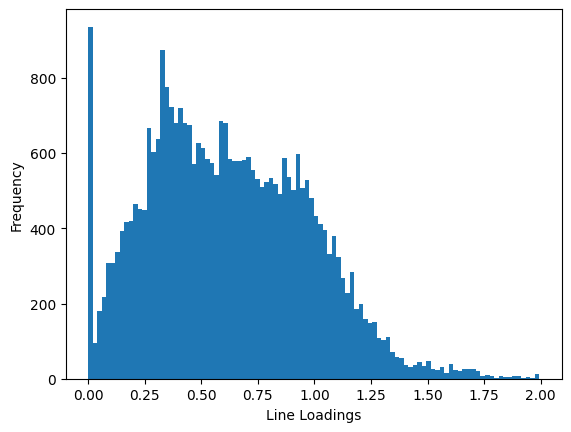

In [23]:
plt.hist(loadings[removed_lines == False], bins=100)
plt.xlabel("Line Loadings")
plt.ylabel("Frequency")
# log scale
plt.savefig(f"loadings_histogram_{prediction_dir}.png")
plt.show()

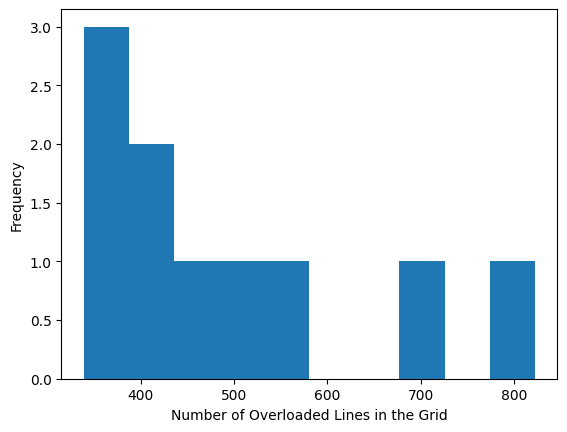

In [24]:
plt.hist((loadings > 1).sum(axis=1))
plt.xlabel("Number of Overloaded Lines in the Grid")
plt.ylabel("Frequency")
# log scale
plt.savefig(f"overload_histogram_{prediction_dir}.png")
plt.show()

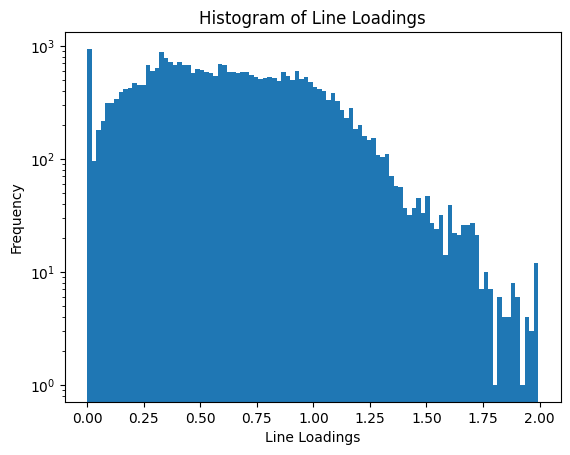

In [25]:
plt.hist(loadings[removed_lines == False], bins=100)
plt.xlabel("Line Loadings")
plt.ylabel("Frequency")
plt.title("Histogram of Line Loadings")
# log scale
plt.yscale("log")
plt.savefig(f"loadings_histogram_log_{prediction_dir}.png")
plt.show()

# Plot pred vs true loadings

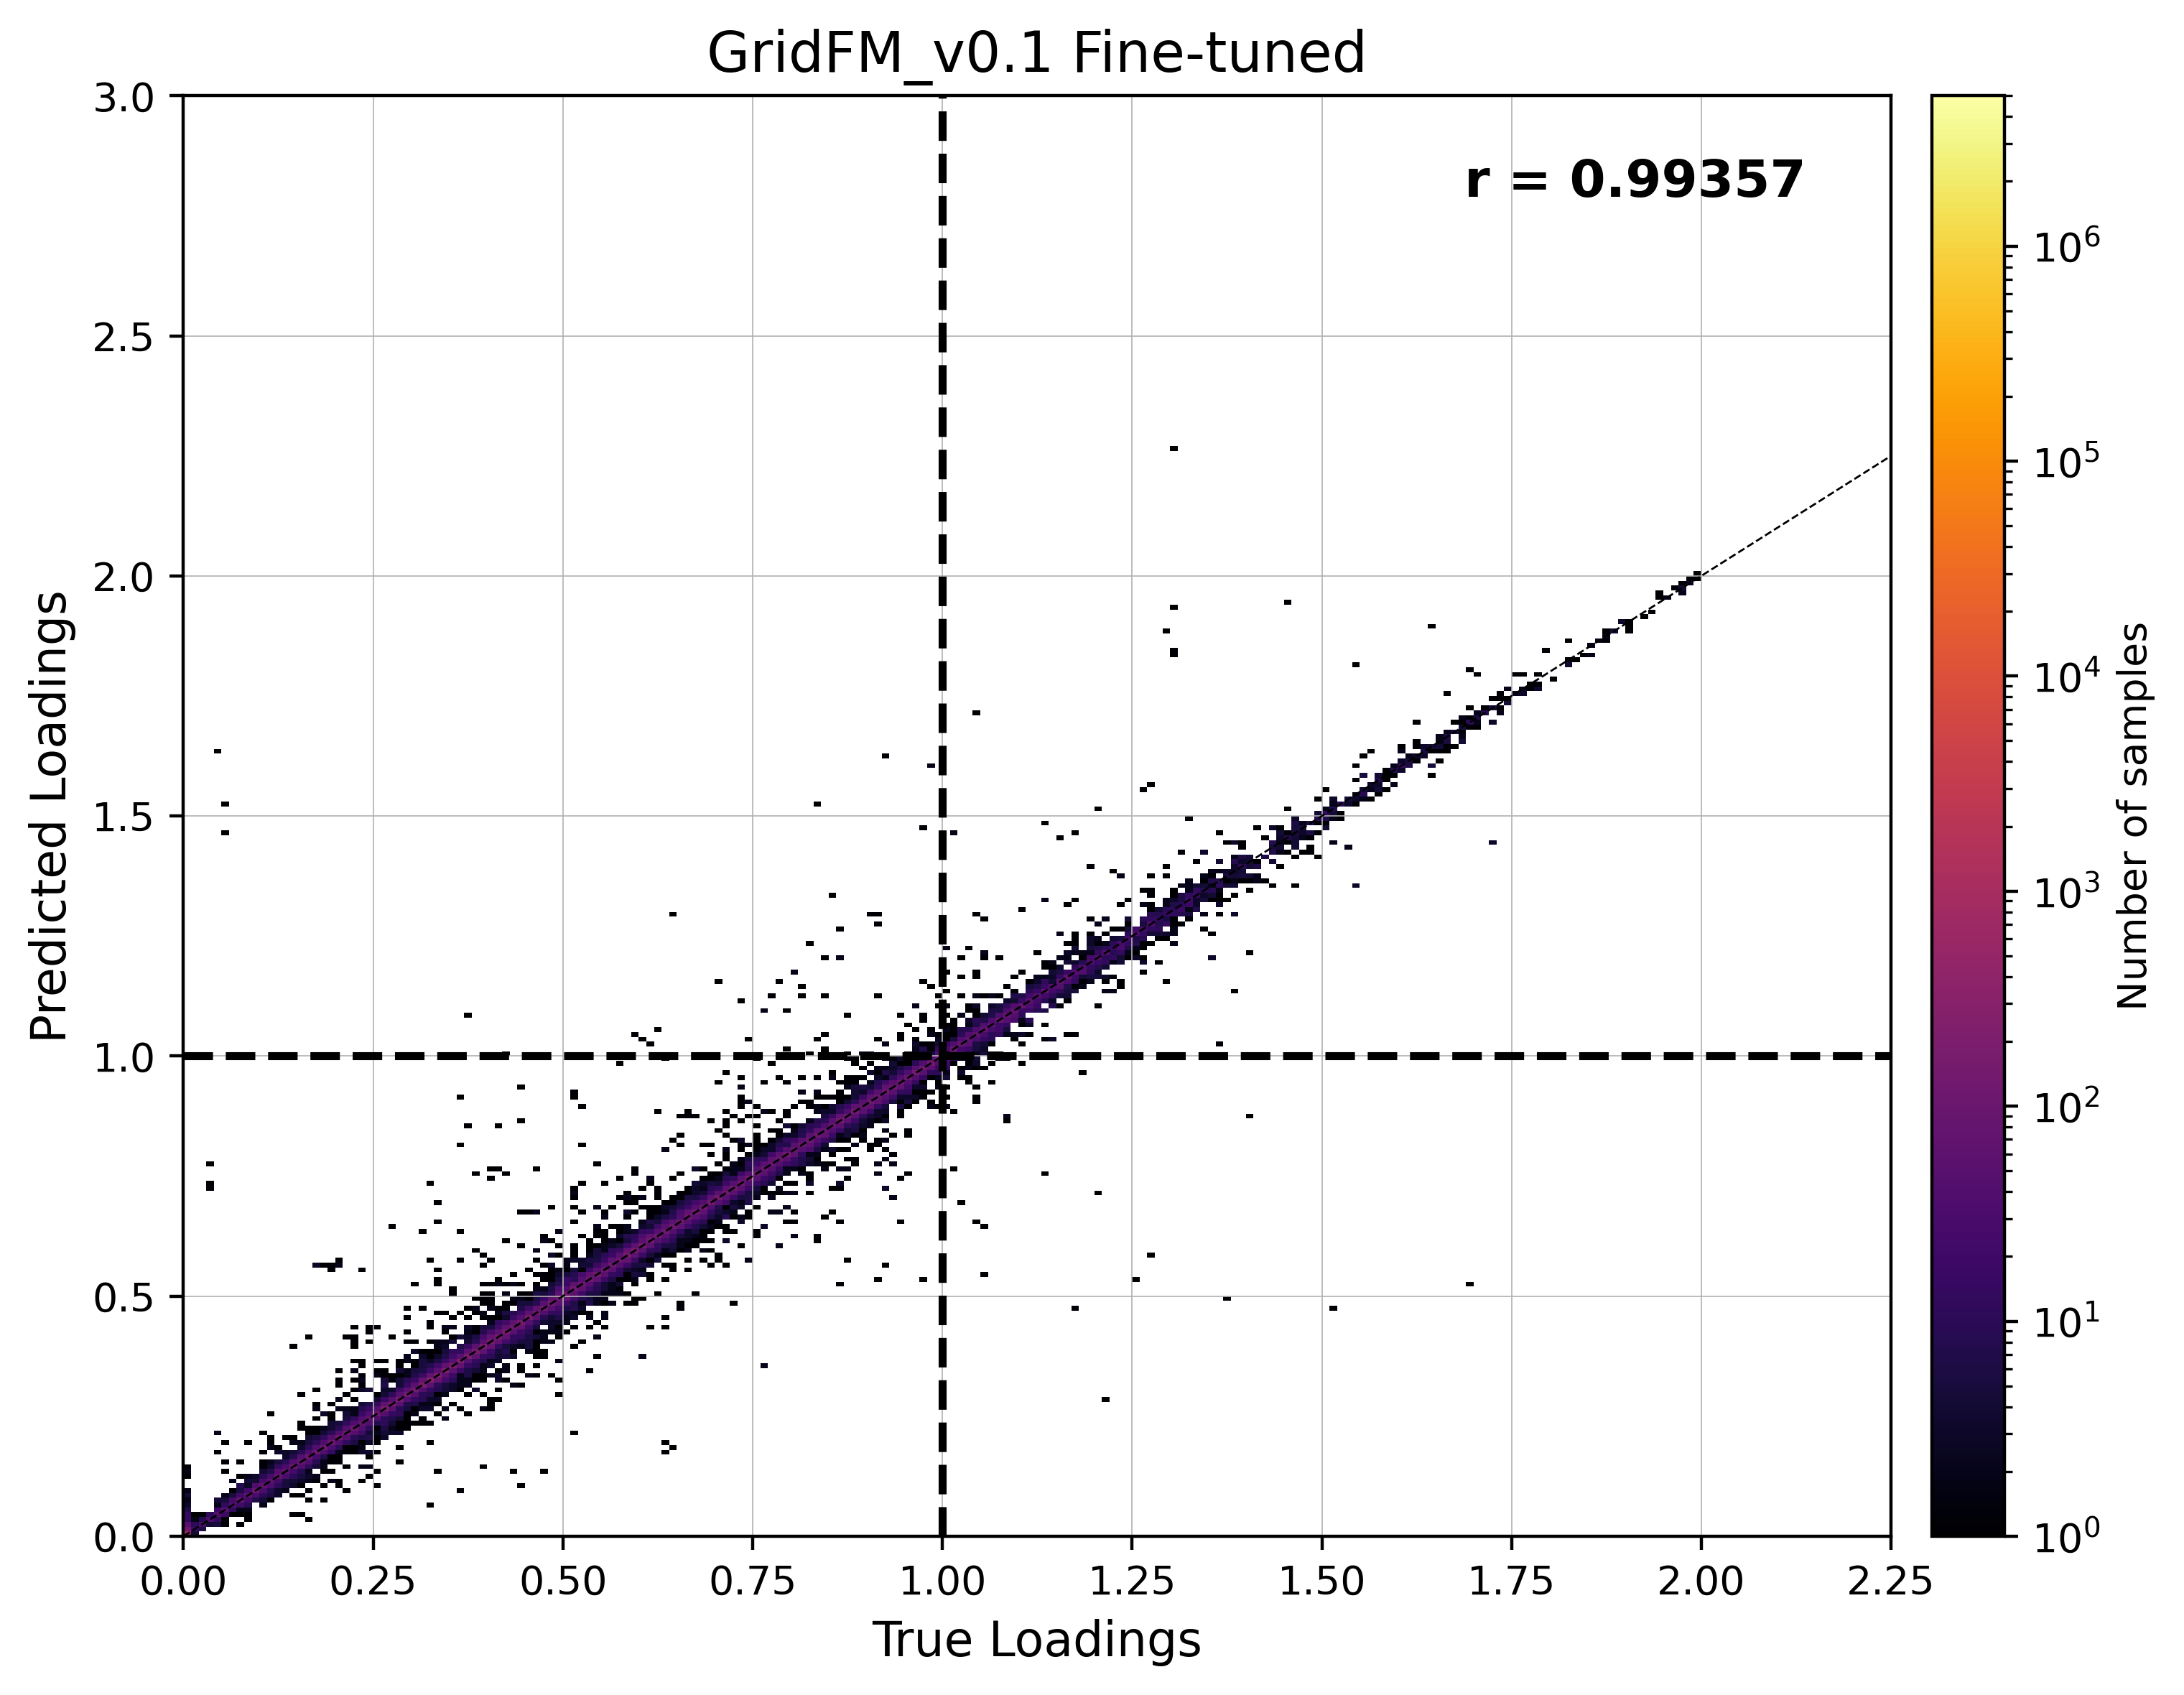

In [26]:
# Define thresholds
true_threshold = 1.00
pred_threshold = 1.00

# Valid lines
valid_mask = removed_lines == False

# Extract valid values
true_vals = loadings[valid_mask]
gfm_vals = loadings_pred[valid_mask]
dc_vals = loadings_dc[valid_mask]

plot_mass_correlation_density(true_vals, gfm_vals, prediction_dir, label_plot)

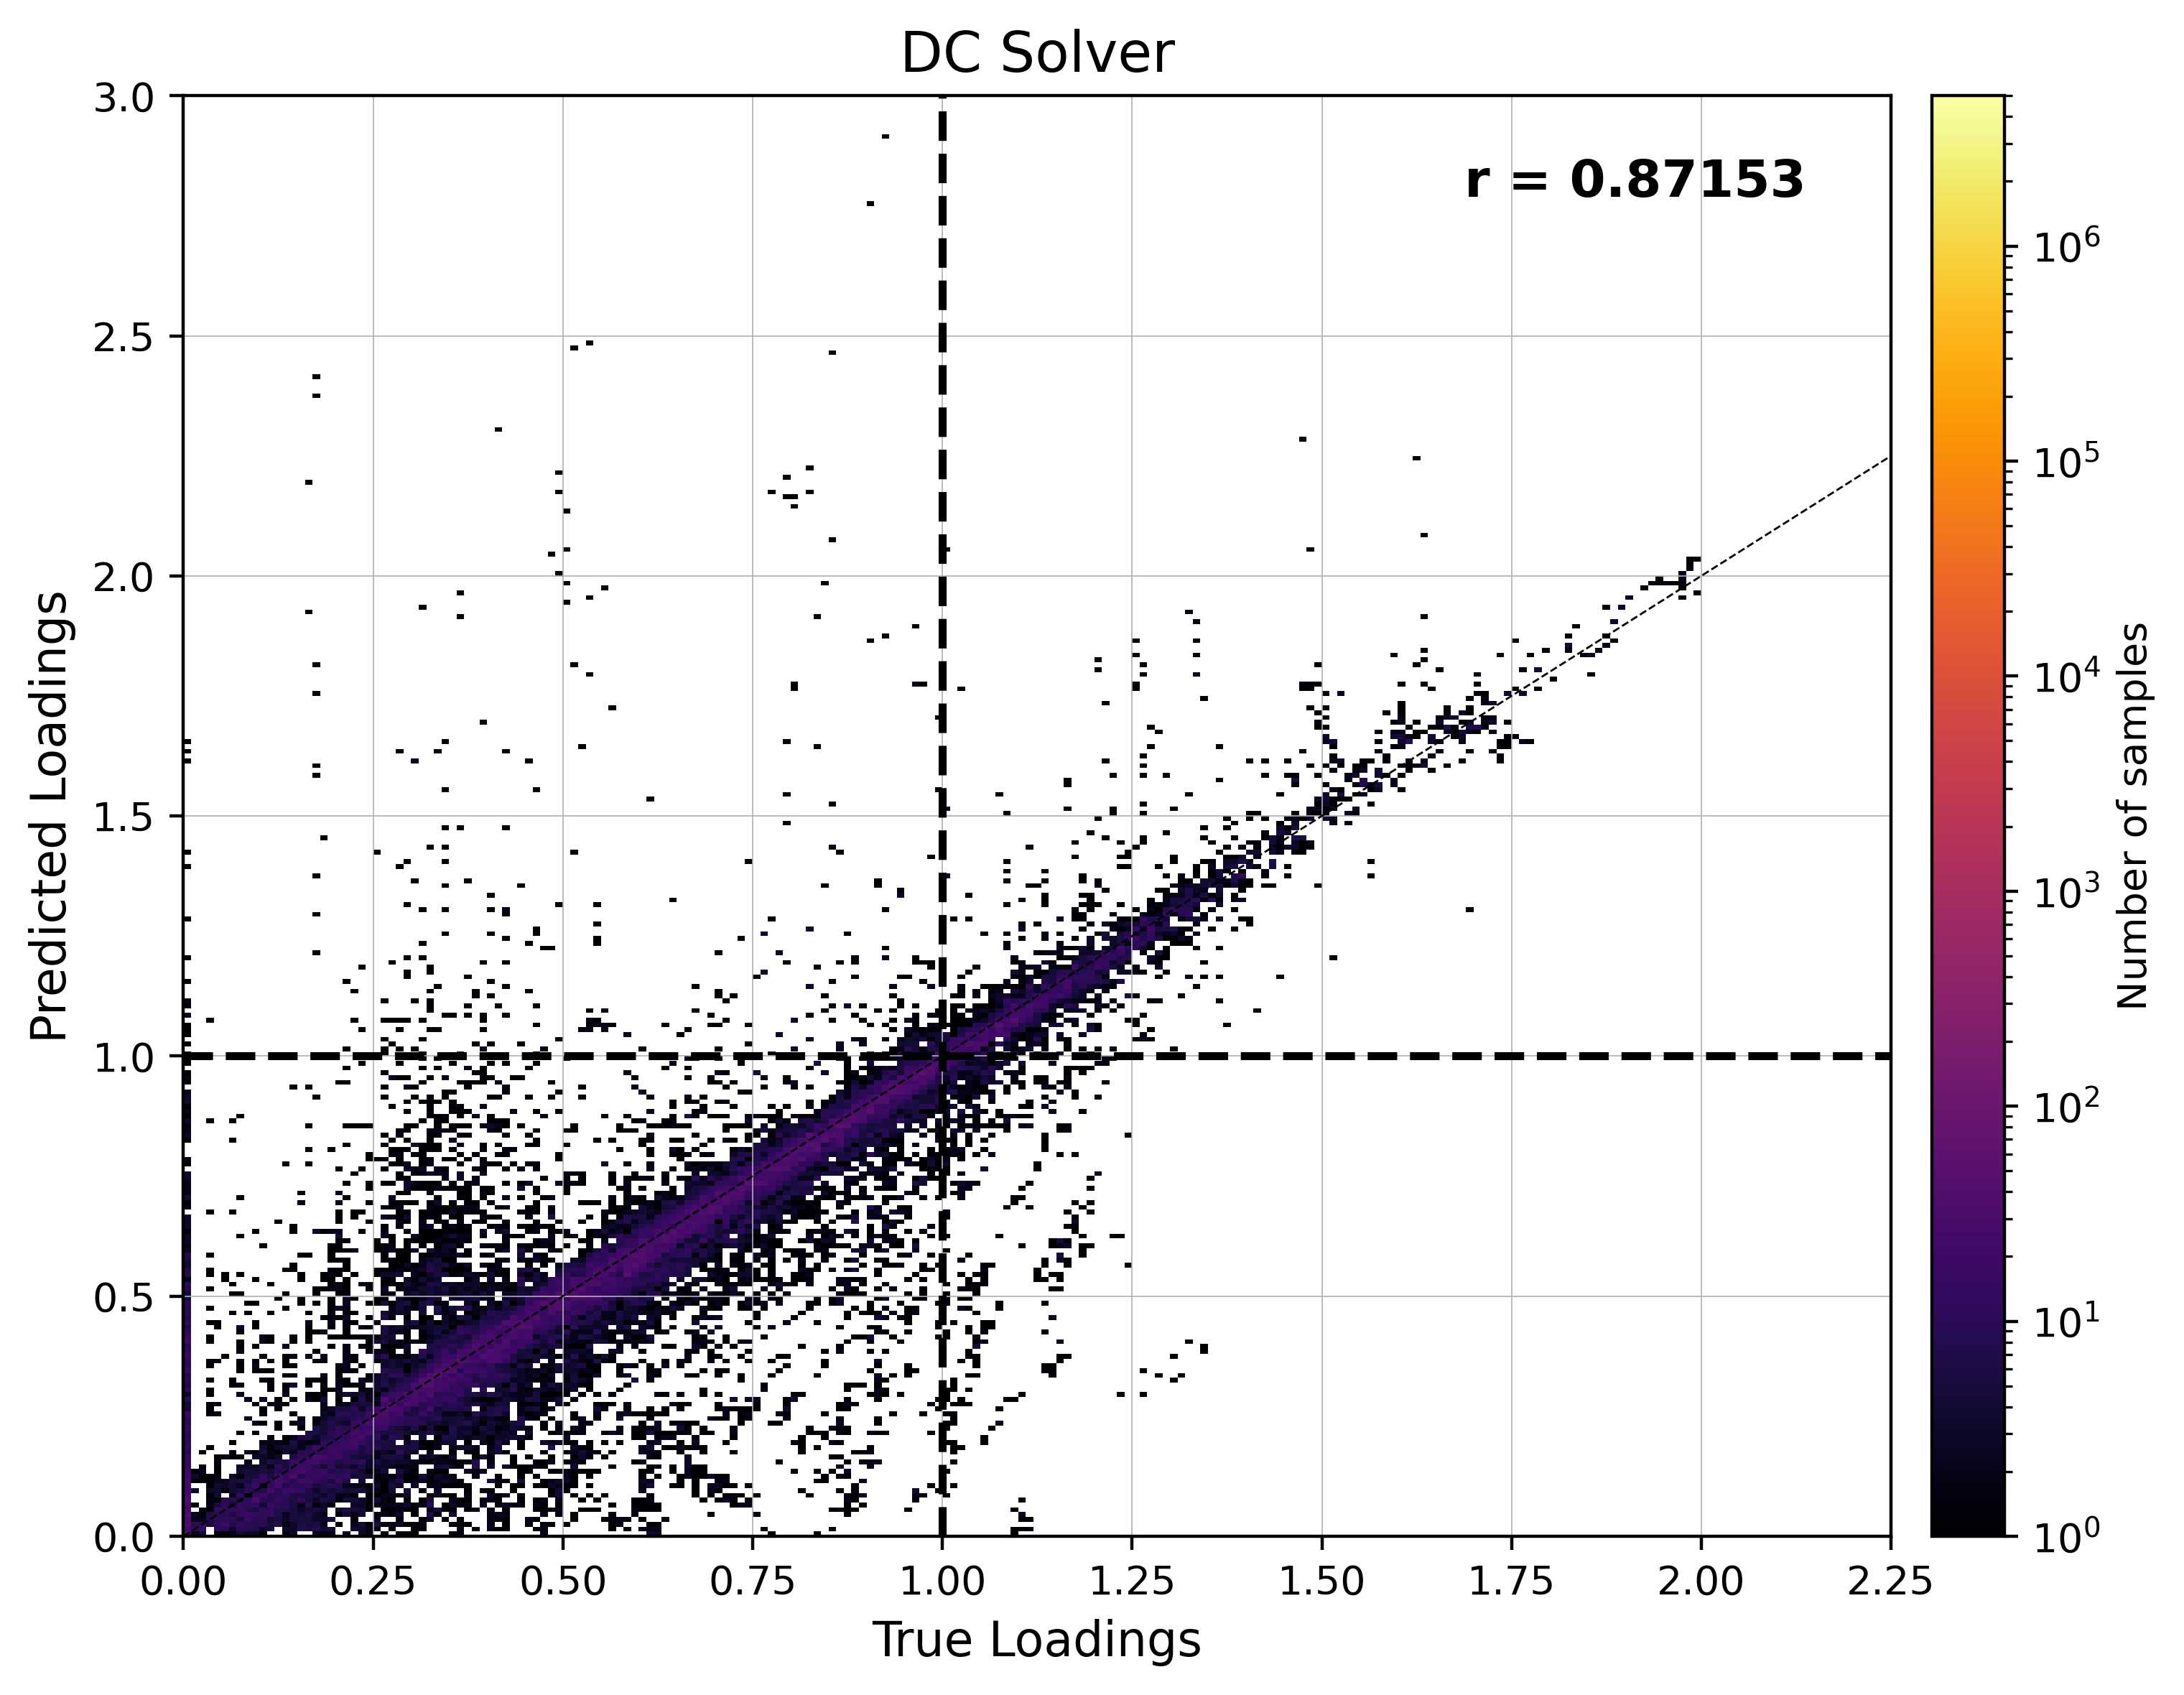

In [27]:
plot_mass_correlation_density(true_vals, dc_vals, "DC", "DC Solver")

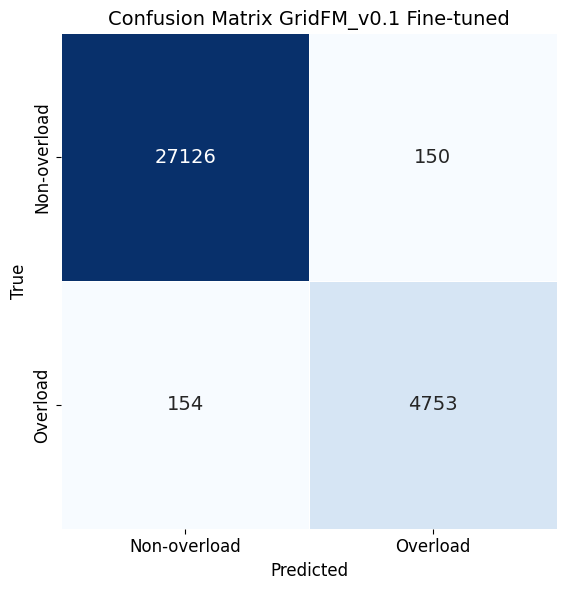

In [28]:
plot_cm(TN_gridfm, FP_gridfm, FN_gridfm, TP_gridfm, prediction_dir, label_plot)

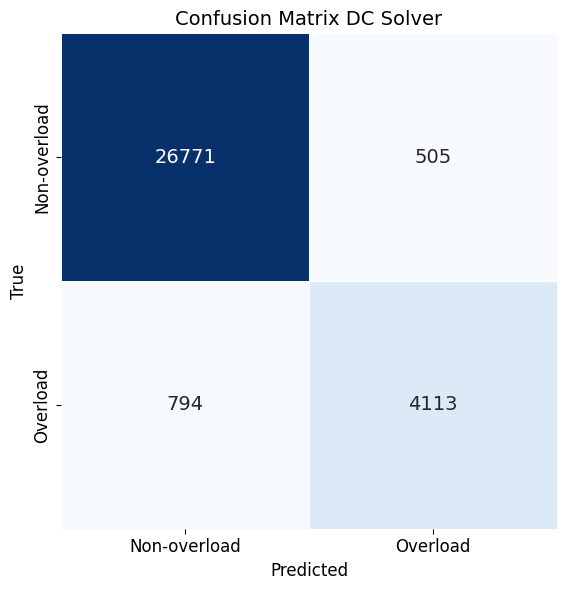

In [29]:
plot_cm(TN_dc, FP_dc, FN_dc, TP_dc, "DC", "DC Solver")

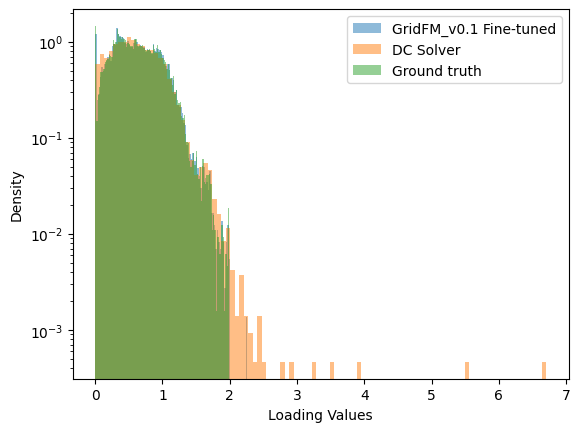

In [30]:
# Histograms of loadings
plot_loading_predictions(
    loadings_pred[removed_lines == False],
    loadings_dc[removed_lines == False],
    loadings[removed_lines == False],
    prediction_dir,
    label_plot,
)

In [31]:
# create df from loadings
loadings_df = pd.DataFrame(loadings)
loadings_df.columns = [f"branch_{i}" for i in range(loadings_df.shape[1])]

loadings_pred_df = pd.DataFrame(loadings_pred)
loadings_pred_df.columns = [f"branch_{i}" for i in range(loadings_pred_df.shape[1])]

In [32]:
loadings_df["scenario"] = pf_node["scenario"].unique()
loadings_pred_df["scenario"] = pf_node["scenario"].unique()

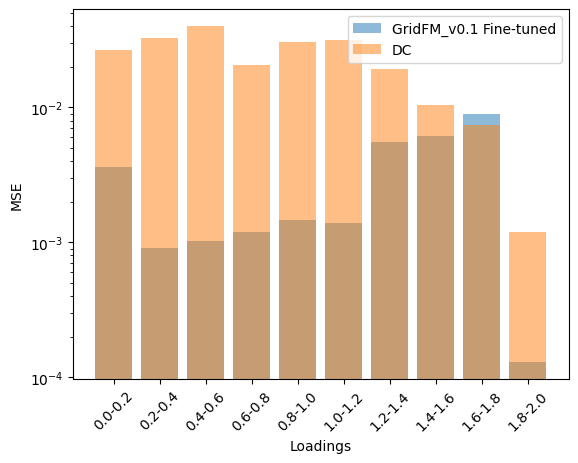

['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0', '1.0-1.2', '1.2-1.4', '1.4-1.6', '1.6-1.8', '1.8-2.0']


In [33]:
# make bar plot of wrongly classified loadings for different bins
bins = np.arange(0, 2.2, 0.2)
mse_pred = []
mse_dc = []
for i in range(len(bins) - 1):
    idx_in_bins = (loadings[removed_lines == False] > bins[i]) & (
        loadings[removed_lines == False] < bins[i + 1]
    )
    mse_pred.append(
        np.mean(
            (
                loadings_pred[removed_lines == False][idx_in_bins]
                - loadings[removed_lines == False][idx_in_bins]
            )
            ** 2
        )
    )
    mse_dc.append(
        np.mean(
            (
                loadings_dc[removed_lines == False][idx_in_bins]
                - loadings[removed_lines == False][idx_in_bins]
            )
            ** 2
        )
    )


# labels
labels = [f"{bins[i]:.1f}-{bins[i + 1]:.1f}" for i in range(len(bins) - 1)]
plt.bar(labels, mse_pred, label=label_plot, alpha=0.5)
plt.bar(labels, mse_dc, label="DC", alpha=0.5)
plt.legend()
plt.xlabel("Loadings")
plt.ylabel("MSE")
# y log scale
plt.yscale("log")
# rotate x labels
plt.xticks(rotation=45)
plt.savefig(f"loading_mse_{prediction_dir}.png")
plt.show()

print(labels)

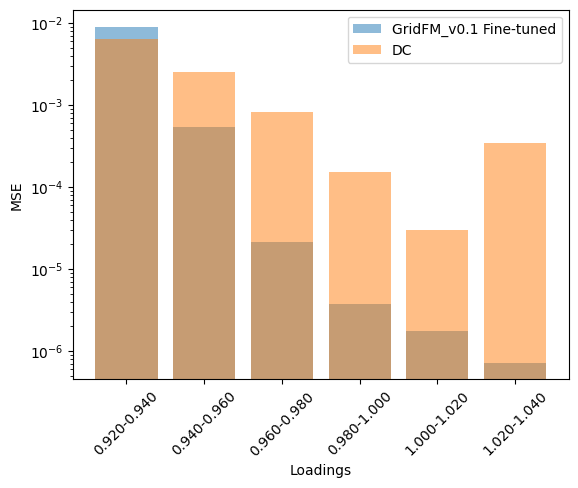

['0.900-0.920', '0.920-0.940', '0.940-0.960', '0.960-0.980', '0.980-1.000', '1.000-1.020', '1.020-1.040']


In [34]:
bins = np.arange(0.9, 1.05, 0.02)
mse_pred = []
mse_dc = []
for i in range(len(bins) - 1):
    idx_in_bins = (pf_node["Vm"] > bins[i]) & (pf_node["Vm"] < bins[i + 1])
    mse_pred.append(
        np.mean(
            (pf_node["Vm_pred_corrected"][idx_in_bins] - pf_node["Vm"][idx_in_bins])
            ** 2
        )
    )
    mse_dc.append(
        np.mean(
            (
                pf_node["Vm_dc_corrected"][idx_in_bins]
                - mean_diff
                - pf_node["Vm"][idx_in_bins].mean()
            )
            ** 2
        )
    )


# labels
labels = [f"{bins[i]:.3f}-{bins[i + 1]:.3f}" for i in range(len(bins) - 1)]
plt.bar(labels, mse_pred, label=label_plot, alpha=0.5)
plt.bar(labels, mse_dc, label="DC", alpha=0.5)
plt.legend()
plt.xlabel("Loadings")
plt.ylabel("MSE")
# y log scale
plt.yscale("log")
# rotate x labels
plt.xticks(rotation=45)
plt.show()

print(labels)

#### Voltage violations

In [35]:
# merge bus_params["vmax"] and bus_params["vmin"] with pf_node on bus_idx
pf_node = pd.merge(pf_node, bus_params[["bus", "vmax", "vmin"]], on="bus", how="left")

In [36]:
# check violations of vmax and vmin with Vm_pred_corrected and Vm
voltage_violations = abs(pf_node["Vm"] - 1) > 0.055
voltage_over_threshold = pf_node["Vm"] > 1.055
voltage_under_threshold = pf_node["Vm"] < 0.945

- Below are the results of GridFM for voltage magnitude violations (GNN version, not transformer, finetuned on PF for IEEE300, and later finetuned on Contingency Data)
- Ground truth is AC PF.
- We use add a safety margin of 0.01 pu to make sure we identify all voltage violations

In [37]:
voltage_violations_pred = abs(pf_node["Vm_pred_corrected"] - 1) > 0.1
TP_gridfm, FP_gridfm, TN_gridfm, FN_gridfm = compute_cm_metrics(
    voltage_violations, voltage_violations_pred, prediction_dir, label_plot
)

Accuracy: 0.998
Confusion Matrix:
TP: 0, FP: 0, TN: 19952, FN: 48
GridFM
TPR: 0.000 (percentage of overloadings correctly predicted)
FPR: 0.000 (percentage of non-overloadings predicted as overloadings)
TNR: 1.00
FNR: 1.00


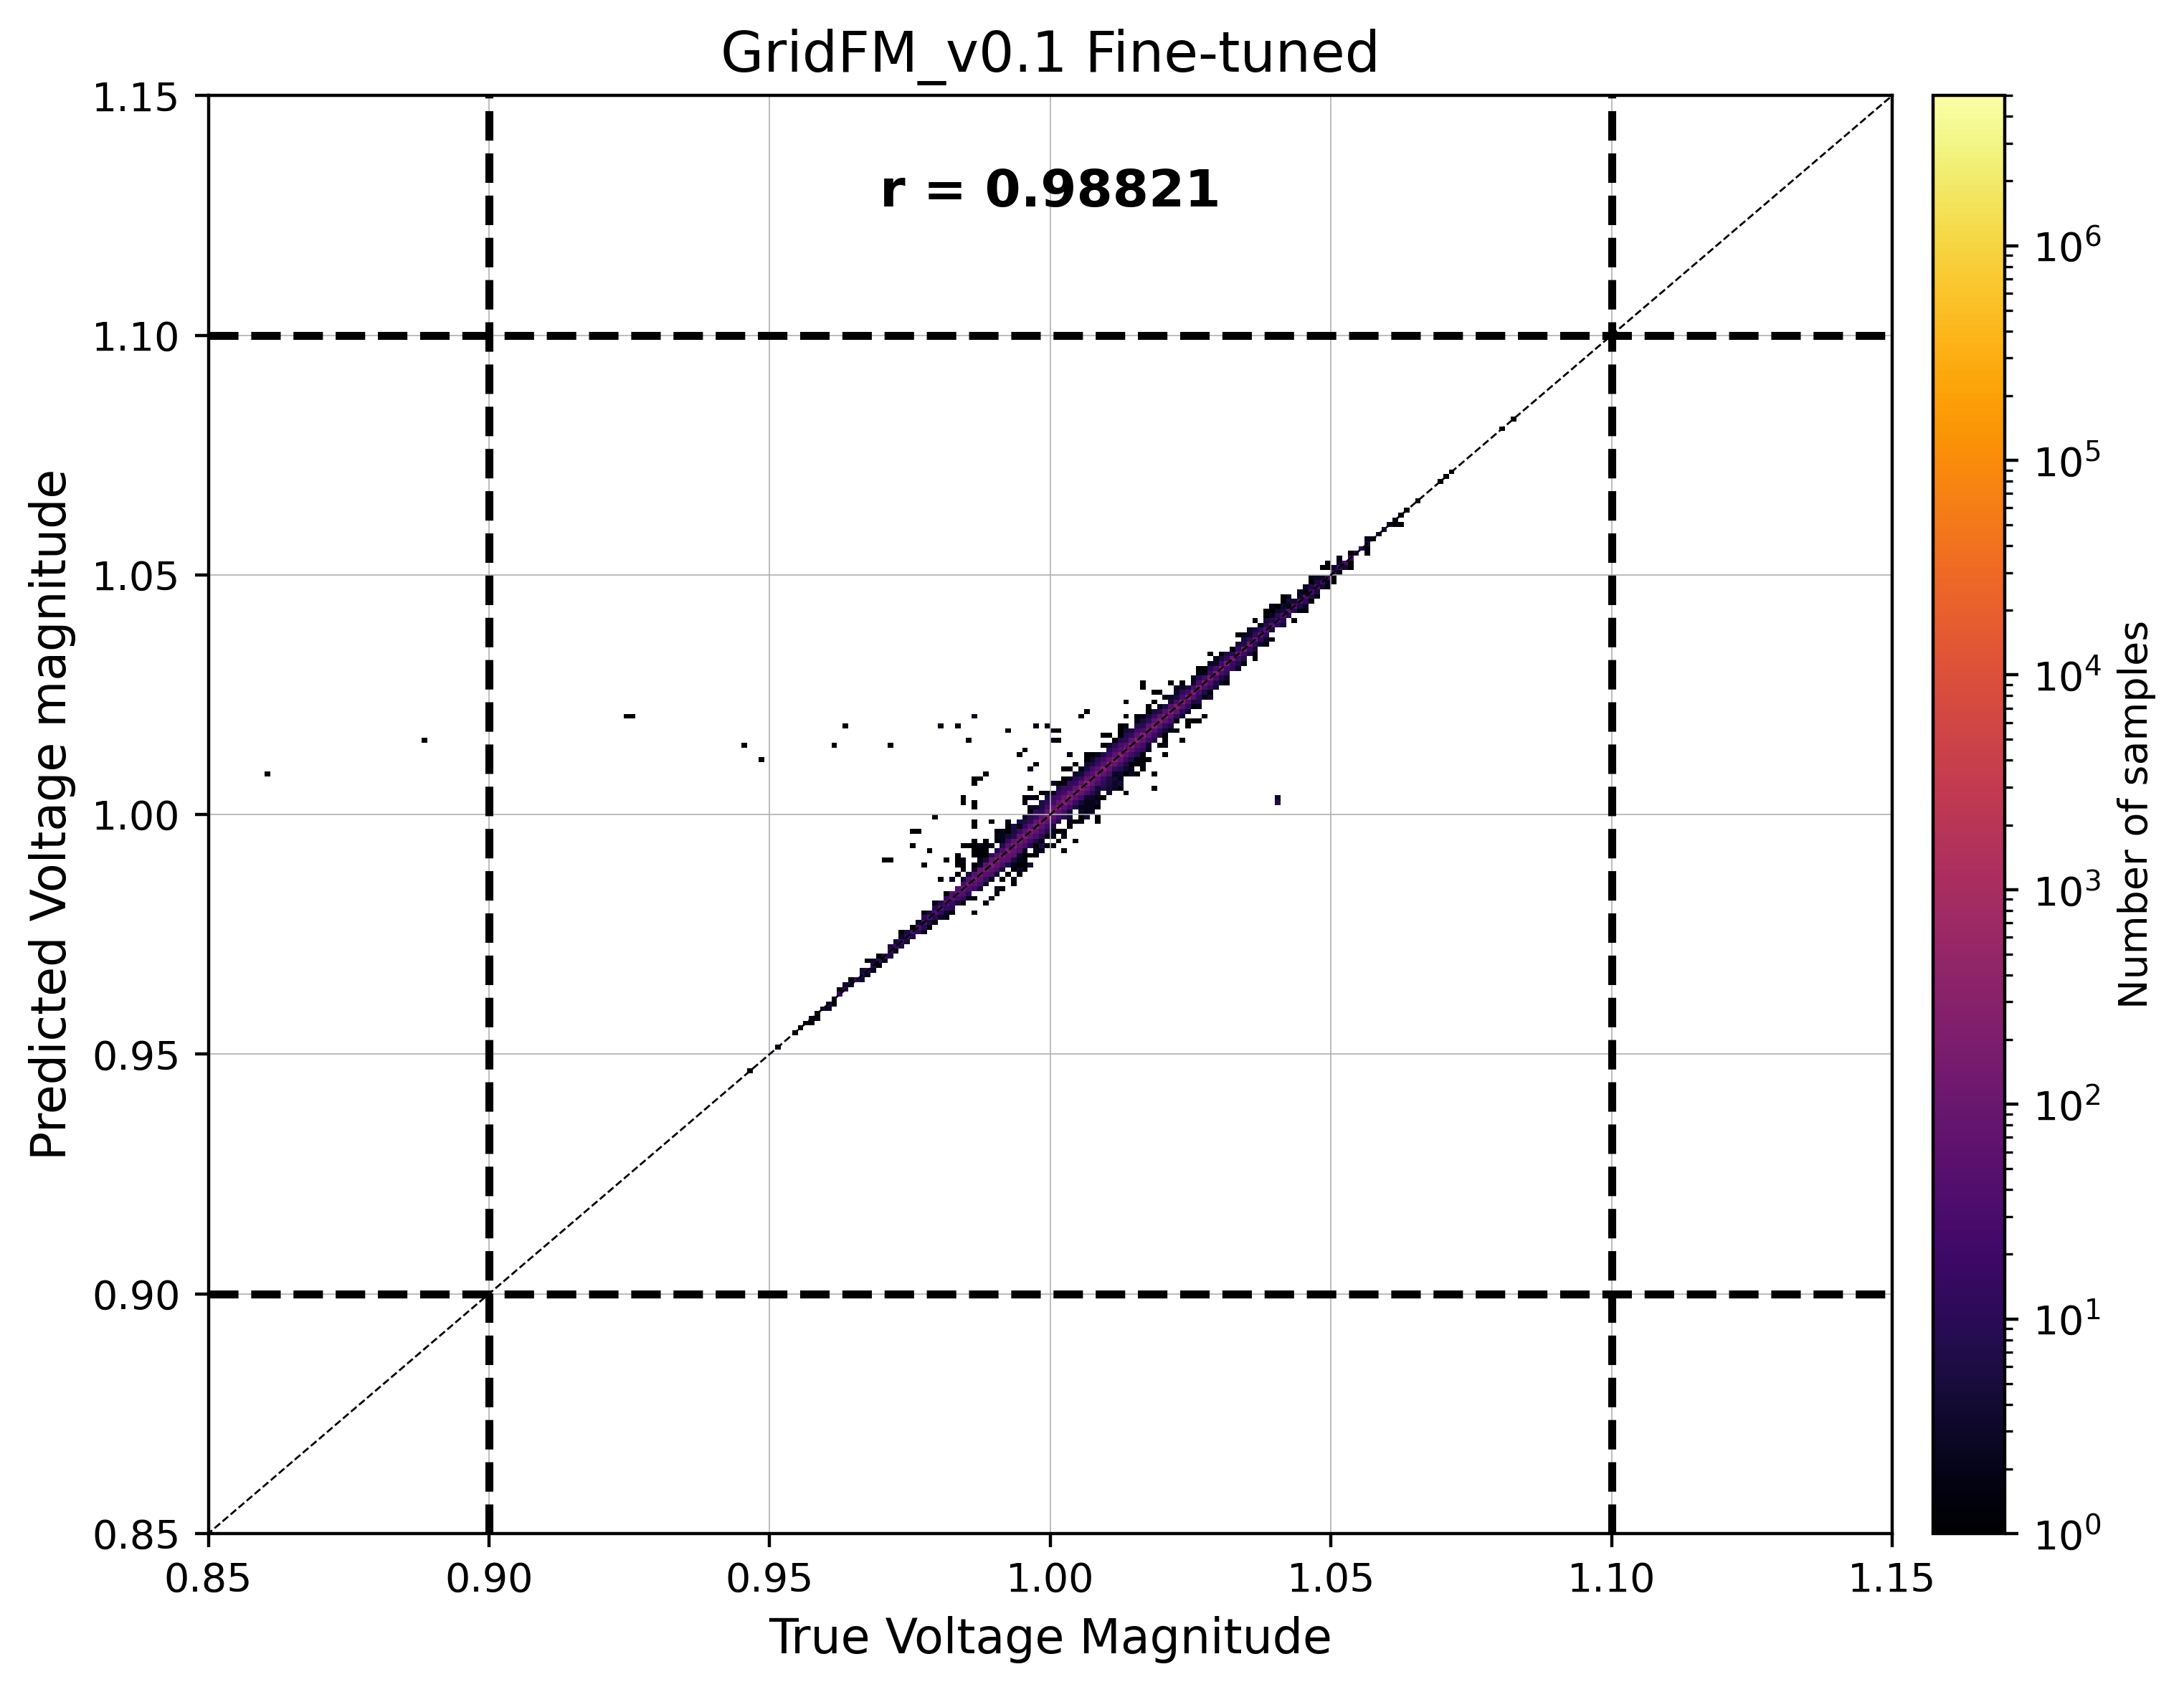

In [38]:
plot_mass_correlation_density_voltage(pf_node, prediction_dir, label_plot)

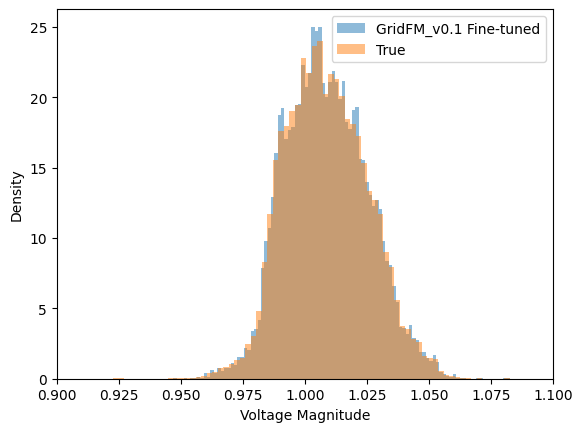

In [39]:
# Histograms of loadings
plt.hist(
    pf_node["Vm_pred_corrected"], alpha=0.5, label=label_plot, density=True, bins=100
)
plt.hist(pf_node["Vm"], alpha=0.5, label="True", density=True, bins=100)

plt.xlabel("Voltage Magnitude")
plt.ylabel("Density")
# plt.yscale("log")
plt.xlim(0.9, 1.1)
plt.legend()
plt.savefig(f"hist_dist_voltage_{prediction_dir}.png")
plt.show()